In [1]:
import os

import numpy as np
import pandas as pd
import networkx as nx
from collections import defaultdict
import json

import matplotlib.pyplot as plt
import fastplot

from datetime import datetime, timedelta
import requests
from time import sleep

from cryptography import x509
from cryptography.hazmat.backends import default_backend

%matplotlib inline


DATA_PATH_PREFIX = ''
if os.path.isdir('data'):
    DATA_PATH_PREFIX = 'data/'

# Filter CCADB Dataset

In [2]:
start_date = datetime(2025, 7, 17)
end_date = datetime(2025, 8, 13)

df_all = pd.DataFrame()
df_roots = pd.DataFrame()

curr_date = start_date
while curr_date <= end_date:
    curr_df = pd.read_csv(f'{DATA_PATH_PREFIX}ccadb/all-certificates_PEM_{curr_date.date()}.csv')
    df_all = pd.concat([df_all, curr_df]).drop_duplicates(subset='SHA-256 Fingerprint', keep='first')

    curr_df = pd.read_csv(f'{DATA_PATH_PREFIX}ccadb/root-certificates_PEM_{curr_date.date()}.csv')
    df_roots = pd.concat([df_roots, curr_df]).drop_duplicates(subset='SHA-256 Fingerprint', keep='first')

    curr_date += timedelta(days=1)

df_all.reset_index(drop=True, inplace=True)
df_roots.reset_index(drop=True, inplace=True)

# Some root certificates have Serial Number "00", which triggers warnings from Cryptography.
def get_subject(pem_info):
    pem_bytes = pem_info[1:-1].encode('utf-8')
    cert = x509.load_pem_x509_certificate(pem_bytes, default_backend())

    return cert.subject.rfc4514_string()

def get_issuer(pem_info):
    pem_bytes = pem_info[1:-1].encode('utf-8')
    cert = x509.load_pem_x509_certificate(pem_bytes, default_backend())
    
    return cert.issuer.rfc4514_string()

    
df_all['Subject'] = df_all['PEM Info'].apply(get_subject)
df_all['Issuer'] = df_all['PEM Info'].apply(get_issuer)
df_roots['Subject'] = df_roots['PEM Info'].apply(get_subject)

invalid_root_certs = set(df_roots.query('`Trust Bits` == "All Trust Bits Turned Off"')['Subject'])

root_certs = set(df_roots['Subject'])
root_certs_email_only = set(df_roots.query('`Trust Bits` == "Email"')['Subject']) # Can ONLY sign for email

df_roots_web = df_roots[df_roots['Trust Bits'].str.contains('Website')]
root_certs_website = set(df_roots_web['Subject']) # Can sign for websites

df = df_all[~df_all['Subject'].isin(root_certs)] # remove root certificates
df = df[~df['Issuer'].isin(invalid_root_certs)] # remove certs issued by the root without Trust Bits
df = df[df['Subject'] != df['Issuer']] # remove self-signed certificates

df_intermediate_email = df[df['Issuer'].isin(root_certs_email_only)] # intermediate directy signed by Mail-only roots
df_intermediate_website = df[df['Issuer'].isin(root_certs_website)] # intermediate directly signed by Web-enabled roots

# Remove level-1 intermediates whose parent is a root with Trust Bits == "Email"
df = df[~df['Issuer'].isin(root_certs_email_only)]

# Remove level-2 intermediate only allowed for Emails
df = df[~(df['Issuer'].isin(df_intermediate_email['Subject']) & ~(df['Issuer'].isin(df_intermediate_website['Subject'])))]

# Keep only rows that include either ExtKeyUsageServerAuth or "1.3.6.1.5.5.7.3.1" (the OID for serverAuth EKU -> https://oid-base.com/get/1.3.6.1.5.5.7.3.1)
serverAuthKeywords = ('ExtKeyUsageServerAuth', '1.3.6.1.5.5.7.3.1')
df = df[df['Extended Key Usage'].apply(lambda r: isinstance(r, float) or any(kw in r.split(',') for kw in serverAuthKeywords))]
df.reset_index(drop=True, inplace=True)

df_roots_web.to_csv(f'{DATA_PATH_PREFIX}web_root_certificates.csv', index=False)
df.to_csv(f'{DATA_PATH_PREFIX}web_intermediate_certificates.csv', index=False)

/tmp/ipykernel_19099/748898375.py:23: CryptographyDeprecationWarning: Parsed a serial number which wasn't positive (i.e., it was negative or zero), which is disallowed by RFC 5280. Loading this certificate will cause an exception in a future release of cryptography.
  cert = x509.load_pem_x509_certificate(pem_bytes, default_backend())


# Analyses

In [3]:
df_cert_interm = pd.read_csv(f'{DATA_PATH_PREFIX}web_intermediate_certificates.csv')
df_cert_root = pd.read_csv(f'{DATA_PATH_PREFIX}web_root_certificates.csv')

df_orgs = pd.read_json(f'{DATA_PATH_PREFIX}operating_CA.json') # Mapping of Certificate Subject Organization to the actual CA
df_cas = pd.read_json(f'{DATA_PATH_PREFIX}CAs.json') # CA Information
df_anchors = pd.read_json(f'{DATA_PATH_PREFIX}anchors.json') # Map intermediate CAs to root CAs

df_root_cas = df_cas.query('Level == 0')
root_countries = set(df_root_cas['Country'])
df_interm_cas = df_cas.query('Level != 0')
interm_countries = set(df_interm_cas['Country']) - root_countries

org_ca_map = df_orgs.set_index('Certificate Organization')['Operating CA'].to_dict()
ca_country_map = df_cas.set_index('CA')['Country'].to_dict()
ca_level_map = df_cas.set_index('CA')['Level'].to_dict()

df_anchors = df_anchors.query('`CA` != `Root CA Anchor`')
df_anchors['To Country'] = df_anchors['CA'].map(ca_country_map)
df_anchors['From Country'] = df_anchors['Root CA Anchor'].map(ca_country_map)
df_anchors = df_anchors[~df_anchors['CA'].isin(df_root_cas['CA'])] # Remove cross-signing between root CAs

## Trust perimeter

In [ ]:
print('Root perimeter:')

print(f'\t{len(df_cert_root)} certificates')
print(f'\t{df_root_cas['CA'].nunique()} CAs')
print(f'\t{len(root_countries)} Countries')
print(f'\t{df_root_cas['CA'].apply(lambda s: s.startswith('Government')).sum()} Governments')

print('Additional intermediate perimeter:')

print(f'\t+{len(df_cert_interm)} certificates')
print(f'\t+{df_interm_cas['CA'].nunique()} CAs')
print(f'\t+{len(interm_countries)} Countries')
print(f'\t+{df_interm_cas['CA'].apply(lambda s: s.startswith('Government')).sum()} Governments')

Root perimeter:
	145 certificates
	46 CAs
	20 Countries
	6 Governments
Additional intermediate perimeter:
	+1686 certificates
	+150 CAs
	+18 Countries
	+3 Governments


## Countries map

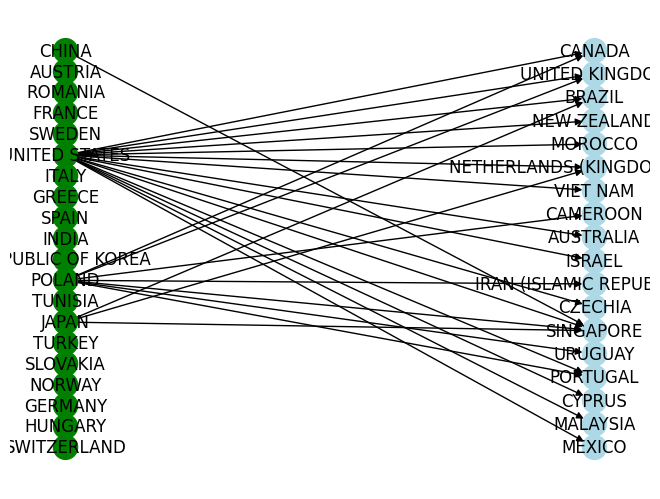

In [5]:
G = nx.DiGraph()
G.add_nodes_from(root_countries)

for _, (c1, c2) in df_anchors[['From Country', 'To Country']].drop_duplicates().query('`From Country` != `To Country`').iterrows():
    G.add_edge(c1, c2)

pos = {}
for i, n in enumerate(root_countries):
    pos[n] = (0, i / max(len(root_countries) - 1, 1))
for i, n in enumerate(interm_countries):
    pos[n] = (1, i / max(len(interm_countries) - 1, 1))
    
node_colors = ['green' if n in root_countries else 'lightblue' for n in G.nodes()]

nx.draw(G, pos, with_labels=True, node_color=node_colors, arrows=True)

# Root countries (hosting one or more root CAs) in green on the left
# Intermediate countries (hosting only intermediate CAs) in light blue on the right

## Policital distance
Distance between the country of each Root CA and countries of all its intermediate CAs

The original csv (available at https://digitallibrary.un.org/record/4060887) has been filtered according to the following code in order to reduce the size of `unga_votes.csv`.

```python
df_un_votes = pd.read_csv('unga_votes.csv')
df_un_votes['date'] = pd.to_datetime(df_un_votes['date'])
df_un_votes = df_un_votes[df_un_votes['date'] >= pd.Timestamp('2020-01-01')]
df_un_votes[['undl_id', 'ms_name', 'ms_vote', 'date']].to_csv('unga_votes.csv', index=False)
```

We did not change thee columns name for compatibility

In [ ]:
df_un_votes = pd.read_csv(f'{DATA_PATH_PREFIX}unga_votes.csv')
df_un_votes['date'] = pd.to_datetime(df_un_votes['date'])
df_un_votes = df_un_votes[df_un_votes['date'] >= pd.Timestamp('2024-01-01')]
df_un_votes = df_un_votes[df_un_votes['date'] < pd.Timestamp('2026-01-01')]

# NOTE: Turkey appears written in three different ways
# 1) TÜRKIYE
# 2) TÜRKÝYE
# 3) TÜRKİYE

df_un_votes['ms_name'] = df_un_votes['ms_name'].apply(lambda n: n if not n.startswith('TÜRK') else 'TURKEY')

In [7]:
def eval_political_distance_from_votes(votes):
    votes = votes.to_list()
    if len(votes) != 2 or 'X' in votes:
        # Both must be present to count the resolution
        return -1

    if votes[0] == votes[1]: 
        return 0 # Complete agreement
    elif 'A' in votes: 
        return 0.5 # Partial agreement (one of the two abstains)
    else:
        return 1 # Complete disagreement

def get_distance(c1, c2):
    if c1 == c2:
        return 0
    t = df_un_votes.query('ms_name == @c1 or ms_name == @c2')
    t = t.groupby('undl_id')['ms_vote'].apply(eval_political_distance_from_votes)
    t = t[t >= 0]
        
    return t.sum() / t.count()

In [8]:
data = defaultdict(list)
distances = dict()

for _, row in df_anchors.iterrows():
    root_ca = row['Root CA Anchor']
    interm_ca = row['CA']

    c1 = row['From Country']
    c2 = row['To Country']

    political_dist = get_distance(c1, c2)
    data[root_ca].append(political_dist)
    distances[f'{c1}->{c2}'] = political_dist

data_sorted = dict(sorted(data.items(), key=lambda e: len(e[1])))

In [9]:
country_codes = {
    'UNITED STATES': 'US',
    'GERMANY': 'DE',
    'POLAND': 'PL',
    'CHINA': 'CN',
    'JAPAN': 'JP',
    'SWITZERLAND': 'CH'
}

def getlabel(name):
    if name == "Deutsche Telekom Security GmbH":
        new_name = "Deutsche Telekom"
    elif name == "Entrust, Inc.":
        new_name = "Entrust"
    elif name == "Asseco Data Systems":
        new_name = "Asseco"
    elif name == "SECOM Co., Ltd.":
        new_name = "SECOM"
    else: 
        new_name = name

    c = ca_country_map[name]
    cc = country_codes[c]
    return f'{new_name} ({cc})'

<module 'matplotlib.pyplot' from '/home/mauro/Documents/PhD/BeyondRootCAs/paper-data/.venv/lib/python3.12/site-packages/matplotlib/pyplot.py'>

<Figure size 640x480 with 0 Axes>

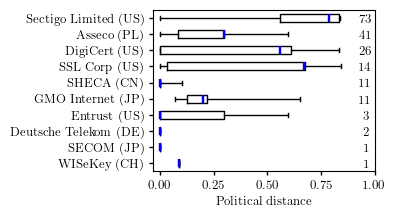

In [10]:
def callback(plt):
    plt.boxplot([v for v in data_sorted.values()], orientation='horizontal', whis=(0, 100), medianprops={'linewidth': 1.75})
    plt.yticks(range(1, 11), [getlabel(k) for k in data_sorted.keys()])
    for i, (k, v) in enumerate(data_sorted.items()):
        n = len(v)
        if n == 1:
            plt.gca().text(0.951, (i + 0.7), n, fontsize=9)
        elif n < 10:
            plt.gca().text(0.944, (i + 0.7), n, fontsize=9)
        else:
            plt.gca().text(0.925, (i + 0.7), n, fontsize=9)

fastplot.plot(None, None, mode='callback', callback=callback, 
                style='latex', 
                xlim=(-0.03, 1), xtick_direction='out', 
                xlabel='Political distance', fontsize=9,
                xticks_fontsize=9, yticks_fontsize=9,
                ytick_direction='out')

## Undisclosed CA certificates

The keywords used to identify 73 certificates that were likely generated to test SSL functionalitites are: 'ssltest', 'testssl', 'demossl', 'valid', 'good', '.tls.', 'revoked', 'expired', 'secomtrust-verification', 'acme.sheca.com', 'catest', 'secom-cert.jp'


In [11]:
with open(f'{DATA_PATH_PREFIX}certificates_from_undeclared_ca_certificates.json', 'r') as f:
    ctlogs_certs = json.load(f)

ctlogs_org_ca_map = { # Certificate Subject Organization names not found in CCADB, therefore not in found in `operating_CA.json`
    "Google UK Ltd.": "Google, Inc.",
    "行政院": "Government of China",
    "Agenzia per l'Italia Digitale": "Government of Italy",
    "SecureCore": "Feitian Japan"
}

data = list()

for cert in ctlogs_certs:
    leaf_sha256 = cert['data']['leaf_cert']['sha256']
    issuer = cert['data']['leaf_cert']['issuer']['aggregated']
    for chain_cert in cert['data']['chain']:
        if chain_cert['subject']['aggregated'] == issuer:
            issuer_sha256 = chain_cert['sha256']
            issuer_org = chain_cert['subject']['O']

            issuer_ca = org_ca_map.get(issuer_org, None)
            if issuer_ca is None:
                issuer_ca = ctlogs_org_ca_map.get(issuer_org, None)
            
            data.append([leaf_sha256, issuer_sha256, issuer_ca])
            break


result = pd.DataFrame(data, columns=['leaf_sha256', 'issuer_sha256', 'issuer_ca'])

if result[result['issuer_ca'].isna()].shape[0] > 0:
    print('NOTE: Same CA certificates were not mapped to the actual CA\n')

result.groupby('issuer_ca')[['issuer_sha256', 'leaf_sha256']].nunique().sort_values('leaf_sha256', ascending=False)

,issuer_sha256,leaf_sha256
issuer_ca,,
DigiCert,10,1395
"Viking Cloud, Inc.",5,147
Government of China,1,104
"TrustAsia Technologies, Inc.",2,91
"SECOM Co., Ltd.",1,6
WoTrus CA Limited,1,4
WebPros International GmbH,1,4
"Entrust, Inc.",1,4
Feitian Japan,1,3


## CT Logs: CAs issuance volume in 2025

To get your API Token, visit cloudflare's dashboard ([dash.cloudflare.com](dash.cloudflare.com)) and:
1. Navigate `Manage account` > `Account API Tokens`
2. Press `Create token`
3. Select the `Read Cloudflare Radar data` template
4. Proceed with the instructions

Note: Cloudflare has a rate limite (per API Token) of 4 requests / second

In [ ]:
CLOUDFLARE_API_TOKEN = None # Set this to your Cloudflare API token with access to the Radar CT API
CT_SUMMARY_URL = "https://api.cloudflare.com/client/v4/radar/ct/timeseries"
HEADERS = {"Authorization": f"Bearer {CLOUDFLARE_API_TOKEN}"}

def get_ca_timeseries(ca):
    request_params = {
        "ca": ca,
        "dateStart": '2025-01-01T00:00:00.000Z',
        "dateEnd": '2025-12-31T23:59:59.999Z',
        "entryType": "CERTIFICATE"
    }
    tries = 0
    while tries < 5:
        try:
            req = requests.get(CT_SUMMARY_URL, headers=HEADERS, params=request_params)
            if req.status_code == 200:
                return req.json()['result']['serie_0']['values']
        except requests.exceptions.ChunkedEncodingError:
            tries += 1
            sleep(60)

    return None

In [17]:
if CLOUDFLARE_API_TOKEN is None:
    print('WARNING: CLOUDFLARE_API_TOKEN is not set. Skipping crawling.')
    with open(f'{DATA_PATH_PREFIX}CTLogs_issuance_volume.json', 'r') as f:
        data = json.load(f)

else:
    data = dict()

    df_cert_interm['Subject CA'] = df_cert_interm['Certificate Subject Organization'].map(org_ca_map)

    for _, (ca, certificates) in df_cert_interm.groupby('Subject CA')['SHA-256 Fingerprint'].agg(set).reset_index().iterrows():
        tot = 0
        for cert in certificates:
            result = get_ca_timeseries(cert)
            sleep(0.35)

            if not result:
                print(f'Could not get data for certificate {cert} from {ca}')
                continue

            tot += sum(int(s) for s in result)

        data[ca] = tot

    with open(f'{DATA_PATH_PREFIX}CTLogs_issuance_volume.json', 'w') as f:
        f.write(json.dumps(data, indent=4, ensure_ascii=False))

print('Certificate issued in 2025:', sum(v for v in data.values()))

Certificate issued in 2025: 28051984724


In [18]:
data_roots = list()
data_intermediates = list() 

for ca, volume in data.items():
    if ca in set(df_root_cas['CA']):
        if volume != 0:
            data_roots.append(volume)
        else:
            data_roots.append(1) # to avoid issues with the log scale
    else:
        if volume != 0:
            data_intermediates.append(volume)
        else:
            data_intermediates.append(1) # to avoid issues with the log scale

<module 'matplotlib.pyplot' from '/home/mauro/Documents/PhD/BeyondRootCAs/paper-data/.venv/lib/python3.12/site-packages/matplotlib/pyplot.py'>

<Figure size 640x480 with 0 Axes>

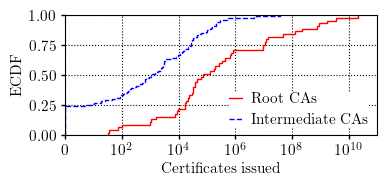

In [19]:
def callback(plt):
    for k, v in [('Root CAs', data_roots), ('Intermediate CAs', data_intermediates)]:
        plt.ecdf(v, label=k, linewidth=1)

fastplot.plot(None, None, figsize=(4,2),
                mode='callback', callback=callback,
                grid=True,
                style='latex', legend=True, legend_args={'handlelength': 0.85, 'borderpad': 0, 'handletextpad': 0.6},
                xscale='log', xlabel='Certificates issued', xlim=(1,1e11),
                xticks=([10**i for i in range(0, 12, 2)],['$10^{' + str(i) + '}$' if i != 0 else 0 for i in range(0, 12, 2)]),
                yticks=([0, .25, .5, .75, 1], ["0.00", "0.25", "0.50", "0.75", "1.00"]),
                xtick_direction='out', ytick_direction='out',
                ylabel='ECDF')